In [1]:
import os
import cv2
import shutil
import numpy as np
import pandas as pd
from glob import glob
import tensorflow as tf
import matplotlib as mplt
import matplotlib.pyplot as plt
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization, GlobalAveragePooling2D,Activation
from tensorflow.keras.layers import Input
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau
from tensorflow.keras.regularizers import l2,l1
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
import joblib
import warnings
warnings.filterwarnings('ignore')

2026-01-20 16:47:47.763807: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768927667.976749      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768927668.039199      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1768927668.554205      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768927668.554266      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768927668.554269      55 computation_placer.cc:177] computation placer alr

In [2]:
x=np.load('/kaggle/input/27-class-sign-language-dataset/X.npy')
y=np.load('/kaggle/input/27-class-sign-language-dataset/Y.npy')

In [3]:
x[0][1][1][1]

np.float32(0.09411765)

In [4]:
print("Images shape:", x.shape)
print("Labels shape:", y.shape)

Images shape: (22801, 128, 128, 3)
Labels shape: (22801, 1)


In [5]:
np.unique(y)

array(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'NULL', 'a', 'b',
       'bye', 'c', 'd', 'e', 'good', 'good morning', 'hello',
       'little bit', 'no', 'pardon', 'please', 'project', 'whats up',
       'yes'], dtype='<U17')

In [6]:
#check data balance or no
pd.Series(y.flatten()).value_counts()

0               866
b               866
whats up        865
no              865
9               865
7               865
6               865
1               865
bye             865
8               865
please          865
5               865
project         865
good            865
pardon          865
yes             865
hello           865
good morning    865
little bit      865
2               865
c               865
3               865
d               865
4               864
a               863
e               863
NULL            314
Name: count, dtype: int64

In [7]:

y = y.squeeze() 
mask = y != 'NULL'
# apply mask
x = x[mask]
y = y[mask]
    

In [8]:
pd.Series(y.flatten()).value_counts()

0               866
b               866
whats up        865
no              865
9               865
7               865
6               865
1               865
bye             865
please          865
8               865
project         865
good            865
pardon          865
yes             865
hello           865
good morning    865
little bit      865
5               865
c               865
3               865
d               865
2               865
4               864
a               863
e               863
Name: count, dtype: int64

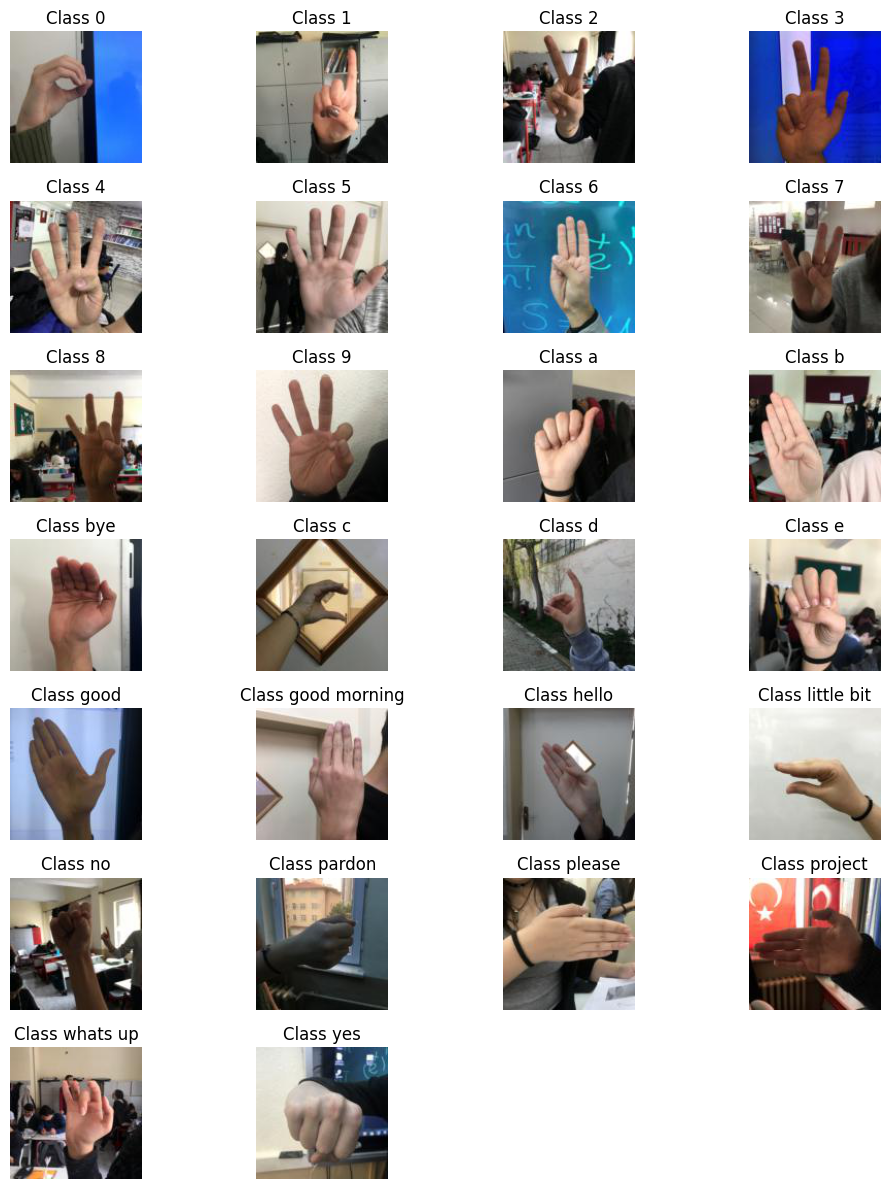

In [9]:

classes = np.unique(y)

plt.figure(figsize=(10, 12))

for i, cls in enumerate(classes):
    plt.subplot(7, 4, i + 1)
    
    index = np.where(y == cls)[0][0]
    plt.title(f"Class {cls}")
    
    img = x[index]
    
    if img.ndim == 3 and img.shape[-1] == 1:
        plt.imshow(img.squeeze(), cmap='gray')
    else:
        plt.imshow(img)  
        
    plt.axis('off')

plt.tight_layout()
plt.show()


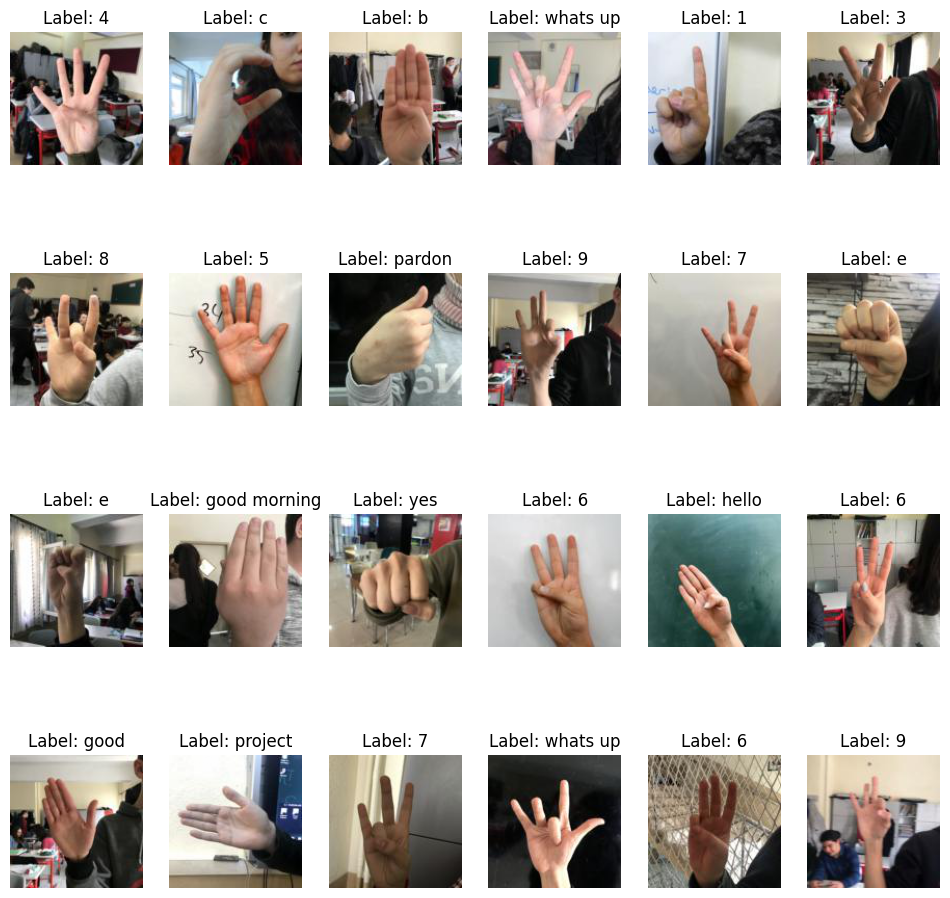

In [10]:

plt.figure(figsize=(12,12))

for i in range(24):
    idx = np.random.randint(0, len(x))
    plt.subplot(4,6,i+1)
    plt.imshow(x[idx])
    plt.title(f"Label: {y[idx]}")
    plt.axis('off')

plt.show()


In [11]:
def hand_coverage(img):
    gray = np.mean(img, axis=-1)
    return np.mean(gray < 200)  # crude threshold

coverages = [hand_coverage(img) for img in x]

print("Min coverage:", np.min(coverages))
print("Max coverage:", np.max(coverages))
print("Mean coverage:", np.mean(coverages))


Min coverage: 1.0
Max coverage: 1.0
Mean coverage: 1.0


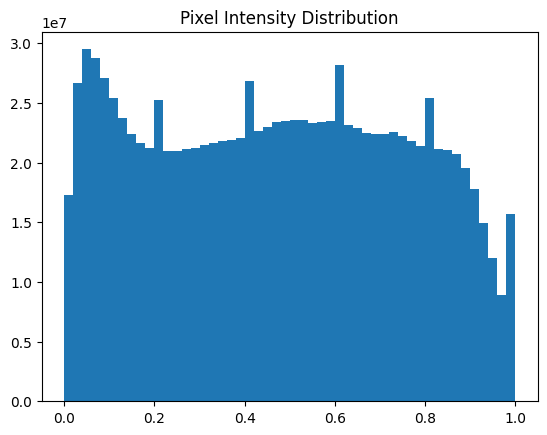

In [12]:
import matplotlib.pyplot as plt

plt.hist(x.flatten(), bins=50)
plt.title("Pixel Intensity Distribution")
plt.show()


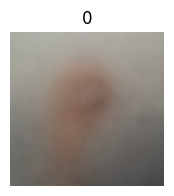

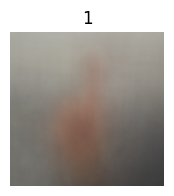

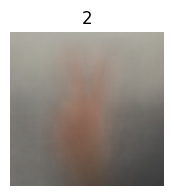

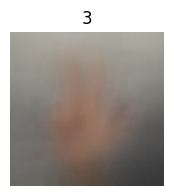

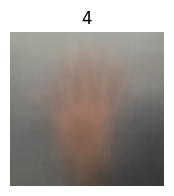

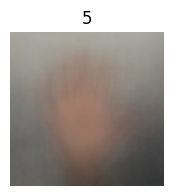

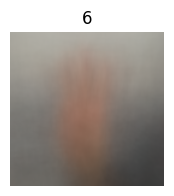

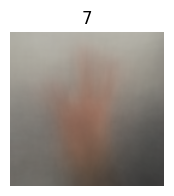

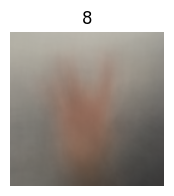

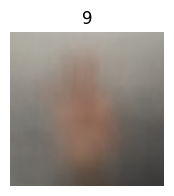

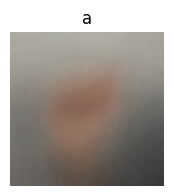

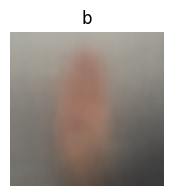

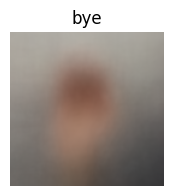

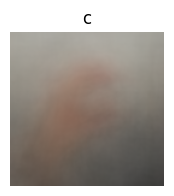

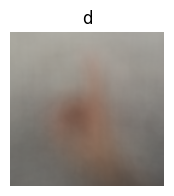

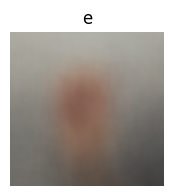

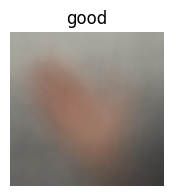

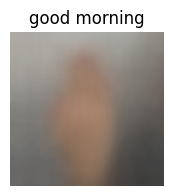

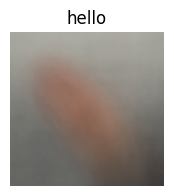

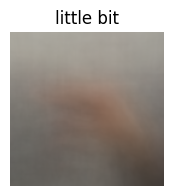

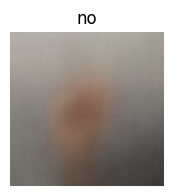

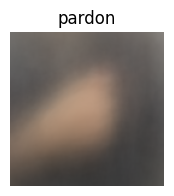

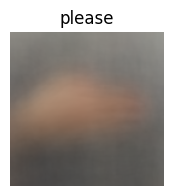

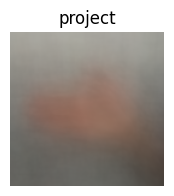

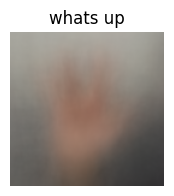

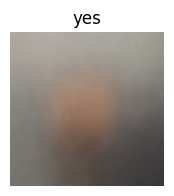

In [13]:
for cls in np.unique(y):
    cls_imgs = x[y.squeeze() == cls]
    mean_cls = np.mean(cls_imgs, axis=0)

    plt.figure(figsize=(2,2))
    plt.imshow(mean_cls)
    plt.title(cls)
    plt.axis('off')
    plt.show()


In [14]:
encoder = LabelEncoder()
y_int = encoder.fit_transform(y)
y_encod=to_categorical(y_int,len(classes))

In [15]:
encoder.classes_


array(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'a', 'b', 'bye',
       'c', 'd', 'e', 'good', 'good morning', 'hello', 'little bit', 'no',
       'pardon', 'please', 'project', 'whats up', 'yes'], dtype='<U17')

In [16]:
x_train,x_test,y_train,y_test=train_test_split(x,y_encod,test_size=0.2,random_state=42)

In [17]:
x_train,x_valid,y_train,y_valid=train_test_split(x_train,y_train,test_size=0.1,random_state=42)

In [18]:
train_datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.4,
    #brightness_range=[0.9, 1.1],
    shear_range=0.15,
    horizontal_flip=False,
)

In [19]:
train_gen=train_datagen.flow(x_train,y_train,batch_size=16,shuffle=True)

In [20]:
train_gen.class_names = classes
print(train_gen.class_names)


['0' '1' '2' '3' '4' '5' '6' '7' '8' '9' 'a' 'b' 'bye' 'c' 'd' 'e' 'good'
 'good morning' 'hello' 'little bit' 'no' 'pardon' 'please' 'project'
 'whats up' 'yes']


In [21]:
val_datagen = ImageDataGenerator()


In [22]:
val_gen=val_datagen.flow(x_valid,y_valid,batch_size=16,shuffle=False)

In [23]:
test_gen = val_datagen.flow(
    x_test, y_test, batch_size=16, shuffle=False
)

# model 1

In [24]:

model = Sequential()
model.add(Input(shape=(128,128,3))) 
# Block 1
model.add(Conv2D(32, (3,3), padding='same', kernel_regularizer=l2(1e-4)))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Conv2D(32, (3,3), padding='same', kernel_regularizer=l2(1e-4)))
model.add(Activation('relu'))
model.add(MaxPooling2D((2,2)))

# Block 2
model.add(Conv2D(64, (3,3), padding='same', kernel_regularizer=l2(1e-4)))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Conv2D(64, (3,3), padding='same', kernel_regularizer=l2(1e-4)))
model.add(Activation('relu'))
model.add(MaxPooling2D((2,2)))

# Block 3
model.add(Conv2D(128, (3,3), padding='same', kernel_regularizer=l2(1e-4)))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Conv2D(128, (3,3), padding='same', kernel_regularizer=l2(1e-4)))
model.add(Activation('relu'))
model.add(MaxPooling2D((2,2)))

# Block 4
model.add(Conv2D(256, (3,3), padding='same', kernel_regularizer=l2(1e-4)))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Conv2D(256, (3,3), padding='same', kernel_regularizer=l2(1e-4)))
model.add(Activation('relu'))
model.add(MaxPooling2D((2,2)))

# Classification head
model.add(GlobalAveragePooling2D())
model.add(Dense(512, activation='relu', kernel_regularizer=l2(1e-4)))
model.add(Dropout(0.5))
model.add(Dense(26, activation='softmax'))  # 27 classes for ASL dataset

# Compile
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()


I0000 00:00:1768927746.155096      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 16, 16, 256)    │             

 Total params: 1,319,098 (5.03 MB)

 Trainable params: 1,318,138 (5.03 MB)

 Non-trainable params: 960 (3.75 KB)

In [25]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [26]:
early_stop = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
   ReduceLROnPlateau(monitor='val_loss',factor=0.1, patience=2,min_lr=1e-6,verbose=1)]


In [27]:

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=45,
    callbacks=[early_stop]
)


Epoch 1/45


I0000 00:00:1768927753.416537     126 service.cc:152] XLA service 0x7ce804086150 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1768927753.416594     126 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1768927754.457067     126 cuda_dnn.cc:529] Loaded cuDNN version 91002


   4/1012 ━━━━━━━━━━━━━━━━━━━━ 53s 53ms/step - accuracy: 0.0716 - loss: 3.4920 

I0000 00:00:1768927761.774744     126 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1012/1012 ━━━━━━━━━━━━━━━━━━━━ 93s 79ms/step - accuracy: 0.0647 - loss: 3.3416 - val_accuracy: 0.1434 - val_loss: 2.9312 - learning_rate: 1.0000e-04
Epoch 2/45
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 69s 68ms/step - accuracy: 0.3192 - loss: 2.3147 - val_accuracy: 0.6793 - val_loss: 1.1294 - learning_rate: 1.0000e-04
Epoch 3/45
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 69s 69ms/step - accuracy: 0.6004 - loss: 1.3548 - val_accuracy: 0.8182 - val_loss: 0.8383 - learning_rate: 1.0000e-04
Epoch 4/45
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 69s 68ms/step - accuracy: 0.7541 - loss: 0.8973 - val_accuracy: 0.8922 - val_loss: 0.4817 - learning_rate: 1.0000e-04
Epoch 5/45
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 70s 69ms/step - accuracy: 0.8375 - loss: 0.6424 - val_accuracy: 0.9305 - val_loss: 0.3752 - learning_rate: 1.0000e-04
Epoch 6/45
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 70s 69ms/step - accuracy: 0.8751 - loss: 0.5344 - val_accuracy: 0.9483 - val_loss: 0.2963 - learning_rate: 1.0000e-04
Epoch 7/45
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 69s 68ms/

In [28]:
def plot_history(history):
    # Accuracy
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='train_acc')
    plt.plot(history.history['val_accuracy'], label='val_acc')
    plt.title(f' Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='train_loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.title(f' Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()



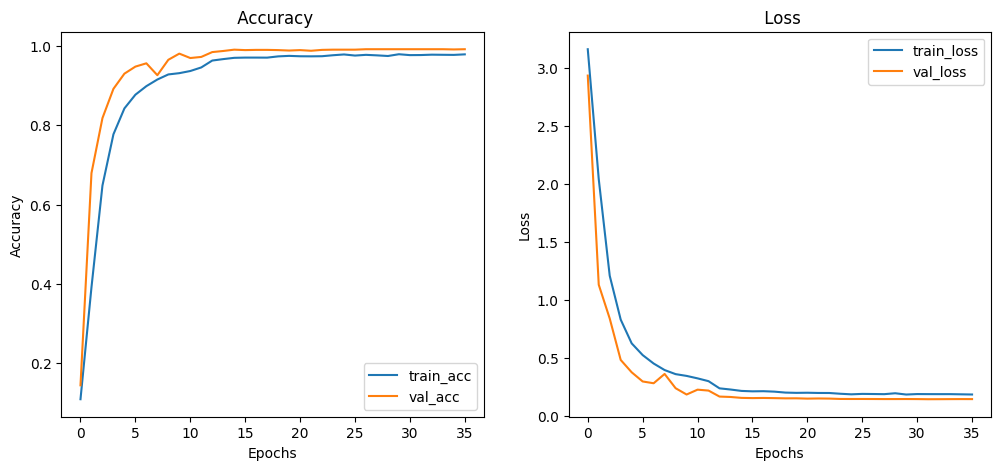

In [29]:
plot_history(history)

In [30]:
model.save("ASL.keras")

In [31]:

model = keras.models.load_model("/kaggle/working/ASL.keras")

# Evaluate on test data
loss, accuracy = model.evaluate(test_gen)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

282/282 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9922 - loss: 0.1507
Test Loss: 0.1454
Test Accuracy: 0.9929


In [32]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = np.argmax(model.predict(test_gen), axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)


282/282 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


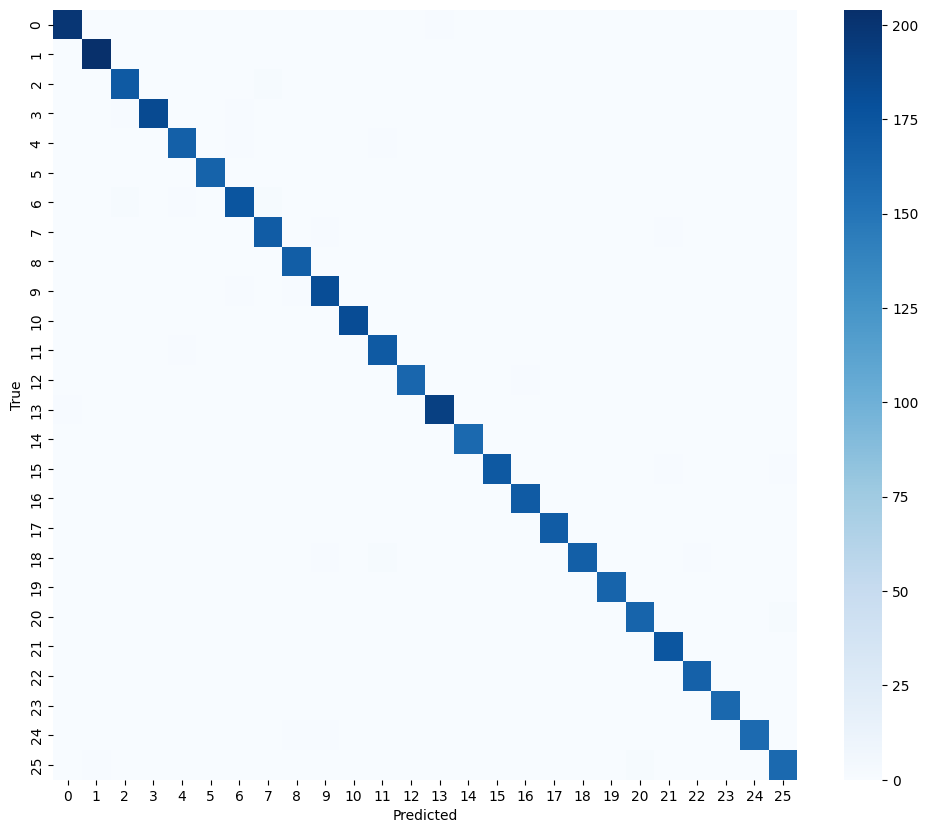

In [33]:
import seaborn as sns
plt.figure(figsize=(12,10))
sns.heatmap(cm, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [34]:
print(classification_report(y_true, y_pred, digits=4))


              precision    recall  f1-score   support

           0     0.9950    0.9950    0.9950       200
           1     0.9951    1.0000    0.9976       204
           2     0.9828    0.9884    0.9856       173
           3     1.0000    0.9892    0.9946       186
           4     0.9881    0.9881    0.9881       168
           5     1.0000    1.0000    1.0000       164
           6     0.9831    0.9722    0.9777       180
           7     0.9769    0.9883    0.9826       171
           8     0.9882    1.0000    0.9941       168
           9     0.9837    0.9891    0.9864       183
          10     1.0000    1.0000    1.0000       182
          11     0.9828    0.9942    0.9884       172
          12     1.0000    0.9938    0.9969       162
          13     0.9948    0.9948    0.9948       193
          14     1.0000    1.0000    1.0000       159
          15     1.0000    0.9885    0.9942       174
          16     0.9942    1.0000    0.9971       170
          17     1.0000    